In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from utils import MyGridWorld, register_gridworld

### cliff walking env

In [2]:
# Create the Cliff Walking env
env = gym.make("CliffWalking", render_mode='rgb_array')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/envs/registration.py:520: UserWarning: WARN: Using the latest versioned environment `CliffWalking-v1` instead of the unversioned environment `CliffWalking`.
  logger.warn(


In [4]:
# Compute size of action & state space
num_actions = env.action_space.n
num_states = env.observation_space.n

print("Number of actions:", num_actions)
print("Number of states:", num_states)

Number of actions: 4
Number of states: 48


In [6]:
# Choose state above goal
STATE_ABOVE_GOAL = 35

# extract transitions for each state-action pair
for action in range(num_actions):
    transitions = env.unwrapped.P[STATE_ABOVE_GOAL][action]
    # Print details of each transition
    for transition in transitions:
        transition_probability, next_state, reward, done = transition
        print(f"Probability: {transition_probability}, Next State: {next_state}, Reward: {reward}, Done: {done} for Action {action}")

Probability: 1.0, Next State: 23, Reward: -1, Done: False for Action 0
Probability: 1.0, Next State: 35, Reward: -1, Done: False for Action 1
Probability: 1.0, Next State: 47, Reward: -1, Done: True for Action 2
Probability: 1.0, Next State: 34, Reward: -1, Done: False for Action 3


### define a deterministic policy

In [2]:
register_gridworld()

MyGridWorld environment registered successfully!


In [38]:
# Create env
# env = gym.make("MyGridWorld", render_mode='rgb_array')
env = MyGridWorld(render_mode='rgb_array')
state, info = env.reset(seed=42)

In [20]:
# Compute size of action & state space
num_actions = env.action_space.n
num_states = env.observation_space.n

print("Number of actions:", num_actions)
print("Number of states:", num_states)

Number of actions: 4
Number of states: 9


In [21]:
# Define the policy
# Actions are represented as: (0 → left, 1 → down, 2 → right, 3 → up).
policy = {
    0:2, 1:2, 2:1,
    5:0, 4:0, 3:1,
    6:2, 7:2
}

In [22]:
def render_custom_env():
    state_image = env.render()
    plt.figure(figsize=(6, 6))
    plt.imshow(state_image)
    plt.axis('off')
    plt.show()

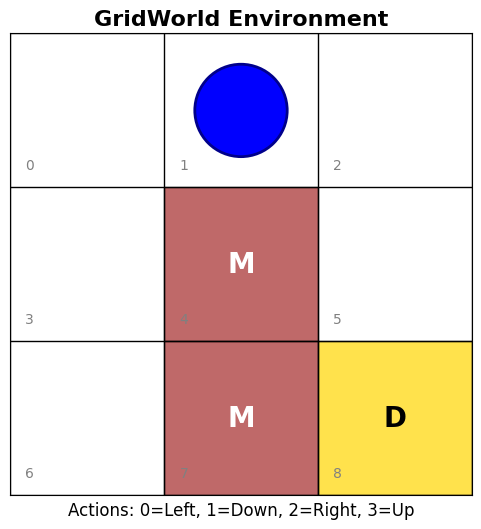

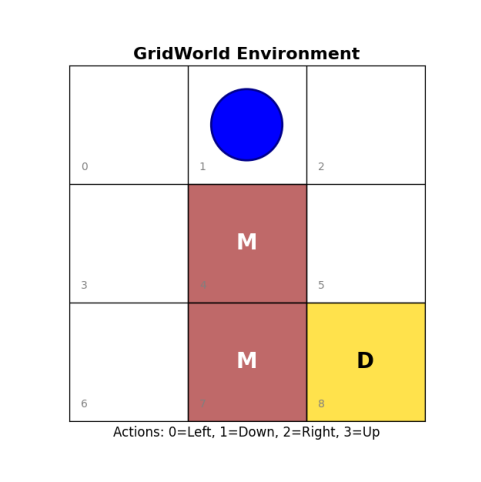

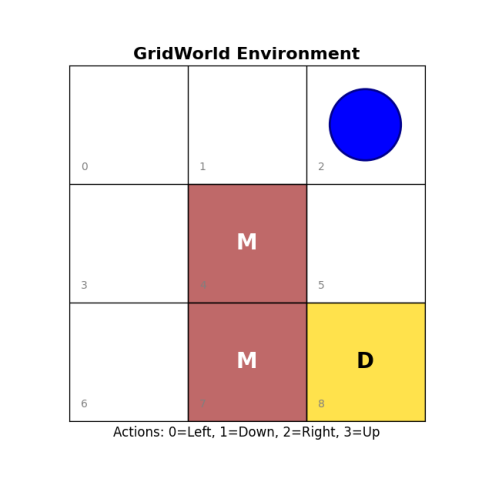

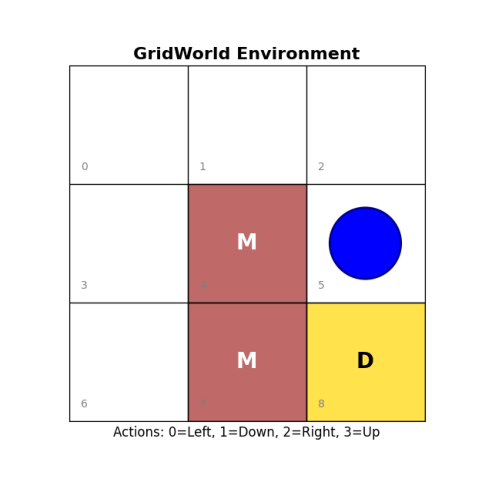

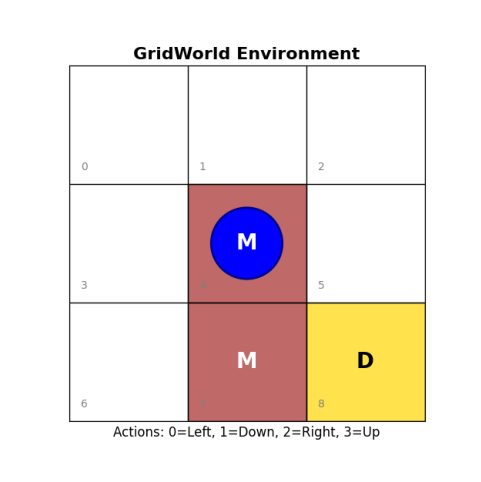

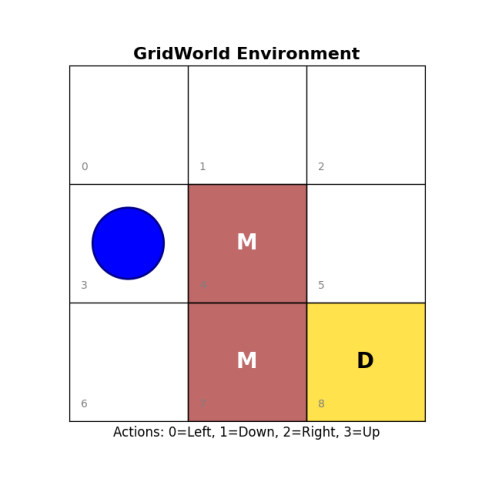

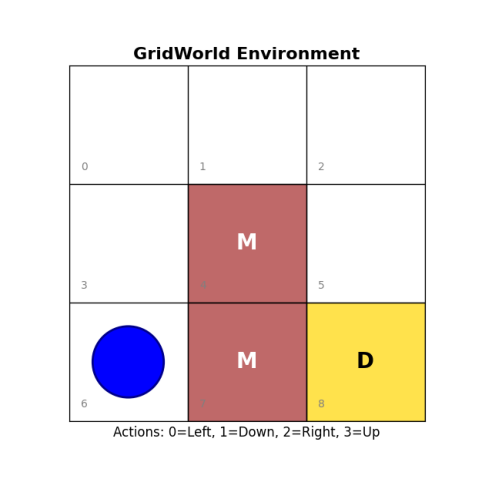

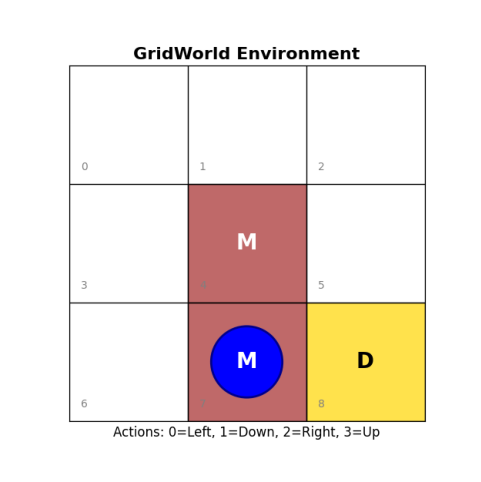

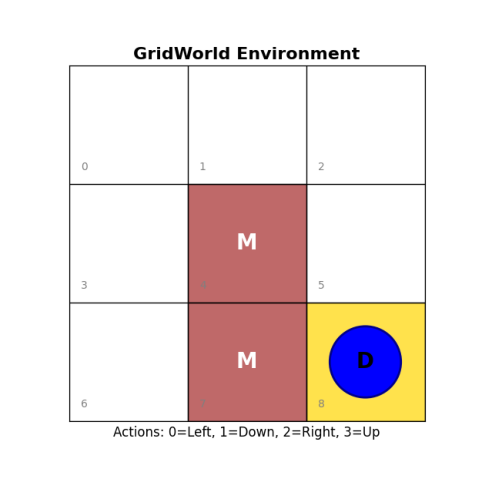

In [23]:
terminated = False
while not terminated:
    # Select action based on policy
    action = policy[state]
    state, reward, terminated, truncated, info = env.step(action)
    # Render the env
    render_custom_env()

In [46]:
# function to compute state-values for a policy
def compute_state_value(state, terminal_state, gamma):
    if state == terminal_state:
        return 0
    action = policy[state]
    _, next_state, reward, _ = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state, terminal_state=terminal_state, gamma=gamma)

In [25]:
TERMINAL_STATE = 8
GAMMA = 1.0

value_function_1 = {0: 1, 1: 2, 2: 3, 3: 7, 4: 6, 5: 4, 6: 8, 7: 10, 8: 0}
value_function_2 = {0: 7, 1: 8, 2: 9, 3: 7, 4: 9, 5: 10, 6: 8, 7: 10, 8: 0}

In [26]:
# compare two policies
# Check for each value in policy 1 if it is better than policy 2
one_is_better = [value_function_1[state] >= value_function_2[state] for state in range(num_states)]

# Check for each value in policy 2 if it is better than policy 1
two_is_better = [value_function_2[state] >= value_function_1[state] for state in range(num_states)]

if all(one_is_better):
  print("Policy 1 is better.")
elif all(two_is_better):
  print("Policy 2 is better.")
else:
  print("Neither policy is uniformly better across all states.")

Policy 2 is better.


### Q-values

In [29]:
# Manually add the P attribute if it's missing
if not hasattr(env, 'P'):
    print("P attribute missing, creating it manually...")
    env.P = {}
    
    for state in range(env.n_states):
        env.P[state] = {}
        
        for action in range(4):  # 4 actions: left, down, right, up
            next_state = env._get_next_state(state, action)
            reward = env._get_reward(next_state)
            terminated = env._is_terminal(next_state)
            
            # Since movements are deterministic, probability is always 1.0
            env.P[state][action] = [(1.0, next_state, reward, terminated)]
    
    print("P attribute created successfully!")

P attribute missing, creating it manually...
P attribute created successfully!


In [32]:
# function to compute the action-value for a state-action pair
def compute_q_values(state, action, terminal_state, gamma=1.0):
    if state == terminal_state:
        return None
    # transition_probability, next_state, reward, done = env.unwrapped.P[state][action][0]
    transition_probability, next_state, reward, done = env.P[state][action][0]
    return reward + gamma * compute_state_value(state, terminal_state=terminal_state, gamma=gamma)

In [35]:
# compute Q values
Q_values_dict = {(state, action): compute_q_values(state, action, terminal_state=TERMINAL_STATE) for state in range(num_states) for action in range(num_actions)}
Q_values_dict

{(0, 0): 0.0,
 (0, 1): 0.0,
 (0, 2): 0.0,
 (0, 3): 0.0,
 (1, 0): 1.0,
 (1, 1): 0.0,
 (1, 2): 1.0,
 (1, 3): 1.0,
 (2, 0): 2.0,
 (2, 1): 2.0,
 (2, 2): 2.0,
 (2, 3): 2.0,
 (3, 0): 6.0,
 (3, 1): 6.0,
 (3, 2): 5.0,
 (3, 3): 6.0,
 (4, 0): 5.0,
 (4, 1): 4.0,
 (4, 2): 5.0,
 (4, 3): 5.0,
 (5, 0): 2.0,
 (5, 1): 14.0,
 (5, 2): 3.0,
 (5, 3): 3.0,
 (6, 0): 7.0,
 (6, 1): 7.0,
 (6, 2): 6.0,
 (6, 3): 7.0,
 (7, 0): 9.0,
 (7, 1): 8.0,
 (7, 2): 20.0,
 (7, 3): 8.0,
 (8, 0): None,
 (8, 1): None,
 (8, 2): None,
 (8, 3): None}

In [40]:
state = 1

In [42]:
# improve policy
improved_policy = {}

for state in range(num_states-1):
    # find the best action for each state based on Q-values
    max_action = max(range(num_actions), key=lambda action: Q_values_dict[(state, action)])
    improved_policy[state] = max_action

In [ ]:
improved_policy
#  Actions are represented as: (0 → left, 1 → down, 2 → right, 3 → up)

# NOTE: this policy is not improved need to fix --> keeps going left in an endless loop

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 0, 7: 2}

In [ ]:
terminated=False
while not terminated:
    # select policy based on action
    action = improved_policy[state]
    # execute the action
    state, reward, terminated, truncated, info = env.step(action)
    render_custom_env()

### policy iteration for optimal policy

In [ ]:
def compute_state_value_policy(state, policy, terminal_state, gamma=1.0):
    if state == terminal_state:
        return 0
    action = policy[state]
    _, next_state, reward, _ = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state, policy, terminal_state=terminal_state, gamma=gamma)


In [ ]:
# policy evaluation function
def compute_state_value_policy(num_states, policy, terminal_state, gamma=1.0):
    V = {state: compute_state_value(state=state, policy=policy, terminal_state=terminal_state, gamma=gamma) for state in range(num_states)}

In [ ]:
# policy evaluation function
def policy_evaluation(policy, num_states, state):
    V = {state: compute_state_value(state, policy) for state in range(num_states)}

In [49]:
# policy improvement function
def policy_improvement(policy, num_states):
    improved_policy = {s: 0 for s in range(num_states-1)}

    # compute Q-values for each state-action pair
    Q = {(state, action): compute_q_values(state, action, policy) for state in range(num_states) for action in range(num_actions)}

    # compute new policy based on Q-values
    for state in range(num_states-1):
        max_action = max(range(num_actions), key=lambda action: Q[(state, action)])
        improved_policy[state] = max_action

    return improved_policy

In [ ]:
# policy iteration function
def policy_iteration(policy, num_states, state):
    while True:
        V = policy_evaluation(policy=policy, num_states=num_states, state=state)
        improved_policy = policy_improvement(policy)

        if improved_policy == policy:
            break
        policy = improved_policy


    return policy, V

In [ ]:
# # usage
# policy = {0:2, 1:2, 2:1, 3:1, 4:0, 5:0, 6:2, 7:2}
# policy, V = policy_iteration()
# render_policy(policy)

In [ ]:
# V = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0}
# policy = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}

In [ ]:
def get_max_action_and_value(state, V, num_actions):
  Q_values = [compute_q_values(state, action, V) for action in range(num_actions)]
  max_action = max(range(num_actions), key=lambda a: Q_values[a])
  max_q_value = Q_values[max_action]
  return max_action, max_q_value

In [ ]:
# Implementing value iteration
threshold = 0.001
while True:
  new_V = {state: 0 for state in range(num_states)}
  for state in range(num_states-1):
    # Get action with maximum Q-value and its value 
    max_action, max_q_value = get_max_action_and_value(state, V)
    # Update the value function and policy
    new_V[state] = max_q_value
    policy[state] = max_action
  # Test if change in state values is negligeable
  if all(abs(new_V[state] - V[state]) < threshold for state in V):
    break
  V = new_V
# render_policy(policy)